# 02 Network Architecture

This notebook mirrors the video's architecture stage, but now grounds candidate selection in the elite archive: compare NNUE shapes, parameter counts, and latency-vs-capacity tradeoffs before longer training runs.

In [2]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns

root = Path.cwd()
sys.path.append(str(root / 'training'))
import nnue_lab_common as c

sns.set_theme(style='whitegrid')

In [ ]:
archive_sample = c.sample_elite_headers(max_games_per_file=120)
tc_mix = archive_sample['tc_class'].value_counts(normalize=True).reindex(['bullet', 'blitz', 'rapid', 'classical', 'unknown'], fill_value=0.0)
speed_share = float(tc_mix[['bullet', 'blitz']].sum())

display(tc_mix.rename_axis('tc_class').reset_index(name='share'))
print('Archive sample size:', len(archive_sample))
print('Fast-game share (bullet+blitz):', round(speed_share, 3))
print('Average sampled Elo:', round(float(archive_sample['avg_elo'].dropna().mean()), 1))

In [ ]:
arch = c.architecture_table().copy()
arch['params_m'] = arch['params'] / 1_000_000
arch['compute_proxy'] = c.FT_SIZE * arch['l1'] + arch['stacks'] * arch['l1'] * arch['l2']
arch['latency_index'] = arch['compute_proxy'] / arch['compute_proxy'].min()
arch['capacity_index'] = arch['params'] / arch['params'].max()
arch['speed_index'] = 1.0 / arch['latency_index']
arch['archive_score'] = (1.0 - speed_share) * arch['capacity_index'] + speed_share * arch['speed_index']
display(arch.sort_values('archive_score', ascending=False))

,name,l1,l2,stacks,skip,psqt,params
1,narrow,192,24,4,8,4,1273252
0,nagato-current,256,32,4,8,4,1697316
2,wide-l2,256,48,4,8,4,1713828
3,wide-l1,320,32,4,8,4,2115172


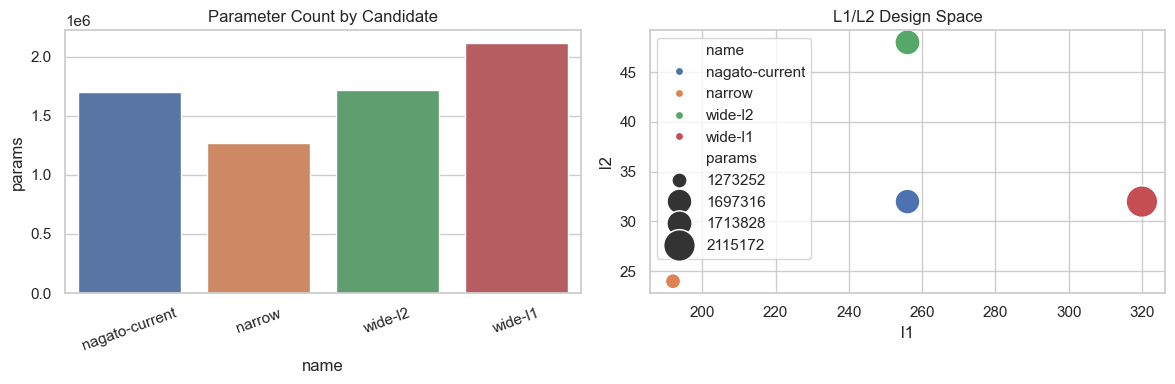

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=arch, x='name', y='params_m', hue='name', ax=axes[0], palette='deep', legend=False)
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_title('Parameter Count by Candidate')
axes[0].set_ylabel('Parameters (millions)')

sns.barplot(data=arch, x='name', y='latency_index', hue='name', ax=axes[1], palette='muted', legend=False)
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_title('Relative Inference Cost')
axes[1].set_ylabel('x baseline')

sns.scatterplot(data=arch, x='latency_index', y='capacity_index', size='archive_score', hue='name', ax=axes[2], sizes=(180, 700))
for _, row in arch.iterrows():
    axes[2].text(row['latency_index'] + 0.01, row['capacity_index'] + 0.005, row['name'], fontsize=9)
axes[2].set_title('Archive-Weighted Tradeoff')
axes[2].set_xlabel('Latency index')
axes[2].set_ylabel('Capacity index')

plt.tight_layout()
plt.show()

In [ ]:
model = c.NagatoNNUE()
best = arch.sort_values('archive_score', ascending=False).iloc[0]
print('Current Nagato params:', model.num_params())
print('FT size:', c.FT_SIZE)
print('Stacks:', c.NUM_STACKS, 'Skip:', c.SKIP, 'PSQT buckets:', c.NUM_PSQT)
print('Archive-prior leader:', best['name'])
print('Leader latency index:', round(float(best['latency_index']), 3), 'archive score:', round(float(best['archive_score']), 3))

Current Nagato params: 1697316
FT size: 6400
Stacks: 4 Skip: 8 PSQT buckets: 4
